In [ ]:
!nvidia-smi

Mon Jun 29 19:25:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip -q install transformers accelerate sentencepiece bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.9 MB/s eta 0:00:00


In [ ]:
import torch
import transformers

print("Torch version:", torch.__version__)
print("Transformers version:", transformers.__version__)
print("CUDA Available:", torch.cuda.is_available())

Torch version: 2.11.0+cu128
Transformers version: 5.12.0
CUDA Available: True


In [ ]:
from transformers import LlavaNextProcessor, LlavaNextForConditionalGeneration
import torch

In [ ]:
model_id = "llava-hf/llava-v1.6-mistral-7b-hf"

In [ ]:
processor = LlavaNextProcessor.from_pretrained(model_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/176 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.25k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.07k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.80M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/41.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

In [ ]:
model = LlavaNextForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto"
)

model.safetensors.index.json:   0%|          | 0.00/70.2k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/687 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/accelerate/utils/modeling.py:1615: UserWarning: The following device_map keys do not match any submodules in the model: ['model.image_newline']
  warnings.warn(


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving dogpark.avif to dogpark.avif


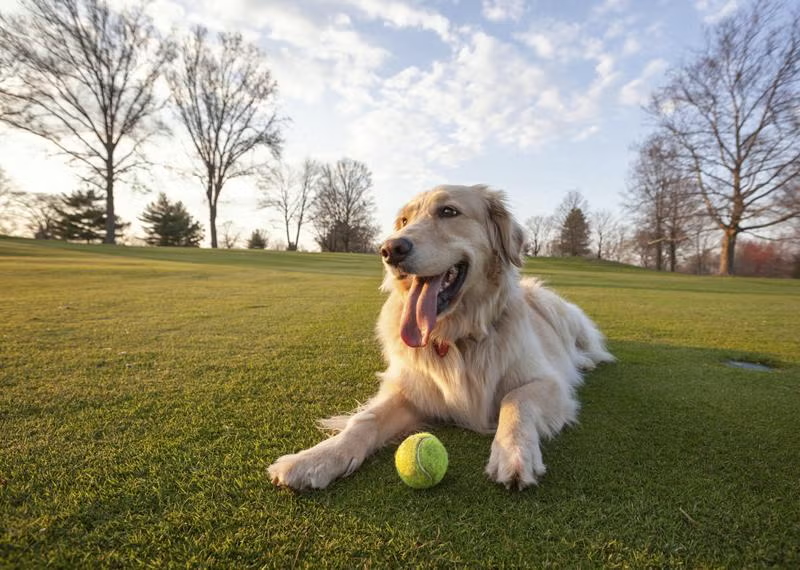

In [ ]:
from PIL import Image

image = Image.open(next(iter(uploaded))).convert("RGB")

image

In [ ]:
prompt = "[INST] <image>\nDescribe this image in detail. [/INST]"

In [ ]:
inputs = processor(
    images=image,
    text=prompt,
    return_tensors="pt"
).to(model.device)

In [ ]:
output = model.generate(
    **inputs,
    max_new_tokens=150,
    do_sample=False
)

[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


In [ ]:
caption = processor.decode(
    output[0],
    skip_special_tokens=True
)

print(caption)

[INST]  
Describe this image in detail. [/INST] In the tranquil setting of a park, a golden retriever dog is the star of this image. The dog, with its golden fur, is lying on a lush green lawn. Its tongue is playfully sticking out, and it's holding a yellow tennis ball in its mouth, ready for a game of fetch.

The dog is positioned in the center of the image, drawing the viewer's attention immediately. Behind it, there's a serene backdrop of trees and a clear blue sky, adding to the peaceful ambiance of the park.

The image captures a moment of joy and relaxation, as the dog enjoys its time outdoors. The vibrant colors of the dog'


In [ ]:
caption = caption.split("[/INST]")[-1].strip()

print(caption)

In the tranquil setting of a park, a golden retriever dog is the star of this image. The dog, with its golden fur, is lying on a lush green lawn. Its tongue is playfully sticking out, and it's holding a yellow tennis ball in its mouth, ready for a game of fetch.

The dog is positioned in the center of the image, drawing the viewer's attention immediately. Behind it, there's a serene backdrop of trees and a clear blue sky, adding to the peaceful ambiance of the park.

The image captures a moment of joy and relaxation, as the dog enjoys its time outdoors. The vibrant colors of the dog'


In [ ]:
import os

os.makedirs("outputs", exist_ok=True)

In [ ]:
with open("outputs/caption.txt", "w") as f:
    f.write(caption)